In [10]:
# Importing basic libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [11]:
df = pd.read_csv("../src/data/raw/machine_failure.csv")

In [12]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# EDA

In [13]:
df.shape

(10000, 14)

In [14]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [16]:
pip install sheryanalysis

Note: you may need to restart the kernel to use updated packages.


In [17]:
import sheryanalysis as sh 

sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (10000, 14)
🧱 Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

✅ No null values found

🔠 Categorical Columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

🔢 Numerical Columns: ['UDI', 'Rotational speed [rpm]', 'Torque [Nm]']

📝 Text Columns: ['Product ID']


{'shape': (10000, 14),
 'columns': ['UDI',
  'Product ID',
  'Type',
  'Air temperature [K]',
  'Process temperature [K]',
  'Rotational speed [rpm]',
  'Torque [Nm]',
  'Tool wear [min]',
  'Machine failure',
  'TWF',
  'HDF',
  'PWF',
  'OSF',
  'RNF'],
 'dtypes': {'UDI': dtype('int64'),
  'Product ID': dtype('O'),
  'Type': dtype('O'),
  'Air temperature [K]': dtype('float64'),
  'Process temperature [K]': dtype('float64'),
  'Rotational speed [rpm]': dtype('int64'),
  'Torque [Nm]': dtype('float64'),
  'Tool wear [min]': dtype('int64'),
  'Machine failure': dtype('int64'),
  'TWF': dtype('int64'),
  'HDF': dtype('int64'),
  'PWF': dtype('int64'),
  'OSF': dtype('int64'),
  'RNF': dtype('int64')},
 'null_counts': {'UDI': 0,
  'Product ID': 0,
  'Type': 0,
  'Air temperature [K]': 0,
  'Process temperature [K]': 0,
  'Rotational speed [rpm]': 0,
  'Torque [Nm]': 0,
  'Tool wear [min]': 0,
  'Machine failure': 0,
  'TWF': 0,
  'HDF': 0,
  'PWF': 0,
  'OSF': 0,
  'RNF': 0},
 'total_row

In [20]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [22]:
df['UDI'].corr(df['Machine failure']) # Its an identifier so we really dont need it no pattern in it its just an identifier

np.float64(-0.02289180554800691)

In [25]:
df['Product ID'].value_counts() # Its also an identifier so we dont need it, becuase it dont have any pattern which is usefull for model

Product ID
M14860    1
L53850    1
L53843    1
L53844    1
L53845    1
         ..
M18193    1
M18194    1
L50515    1
L50516    1
M24859    1
Name: count, Length: 10000, dtype: int64

In [27]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [97]:
from pandas.api.types import is_numeric_dtype
from matplotlib.axes import Axes


def histogram(
    column: pd.Series,
    dataframe: pd.DataFrame | None,
    kde: bool,
    bins: int
) -> tuple[Axes, str, dict] | None:

    try:
        # DataFrame validation

        if dataframe is None:
            print("Err: DataFrame can't be None!")
            return None

        if len(dataframe) == 0:
            print("Err: DataFrame can't have a length of 0!")
            return None

        # Column validation

        if column is None:
            print("Err: Column can't be None!")
            return None

        if column not in dataframe.columns:
            print("Err: Column doesn't exist in DataFrame!")

            quant_cols: list[str] = dataframe.select_dtypes(
                include="number"
            ).columns.tolist()

            print(f"Available quantitative columns: {quant_cols}")

            return None

        if len(column) == 0:
            print("Err: Column name can't have a length of 0!")
            return None

        # Column dtype validation

        is_col_valid_dtype: bool = is_numeric_dtype(
            dataframe[column]
        )

        if not is_col_valid_dtype:
            print("Err: Histogram requires a numerical column!")
            return None

        # KDE and bins validation

        is_kde_bool: bool = isinstance(kde, bool)
        is_bins_int: bool = isinstance(bins, int)

        if not is_kde_bool:
            print("Err: KDE must be boolean!")
            return None

        if not is_bins_int:
            print("Err: Bins must be an integer!")
            return None

        # Create histogram

        plot: Axes = sns.histplot(
            dataframe[column],
            kde=kde,
            bins=bins
        )

        # Return

        summary: str = "Histogram successfully plotted!"
        stats = {
            'mean': dataframe[column].mean(),
            'median': dataframe[column].median(),
            'std': dataframe[column].std(),
            'min': dataframe[column].min(),
            'max': dataframe[column].max(),
            'count': len(dataframe[column]),
            'skewness': dataframe[column].skew(),
            'kurtosis': dataframe[column].kurtosis()
        }

        return (plot, summary, stats)

    except Exception as err:

        print(f"Err: Occurred due to: {err}")

        return None

(<Axes: xlabel='Air temperature [K]', ylabel='Count'>,
 'Histogram successfully plotted!',
 {'mean': np.float64(300.00493),
  'median': 300.1,
  'std': 2.0002586829157574,
  'min': 295.3,
  'max': 304.5,
  'count': 10000,
  'skewness': np.float64(0.11427392052155025),
  'kurtosis': np.float64(-0.8359616725774686)})

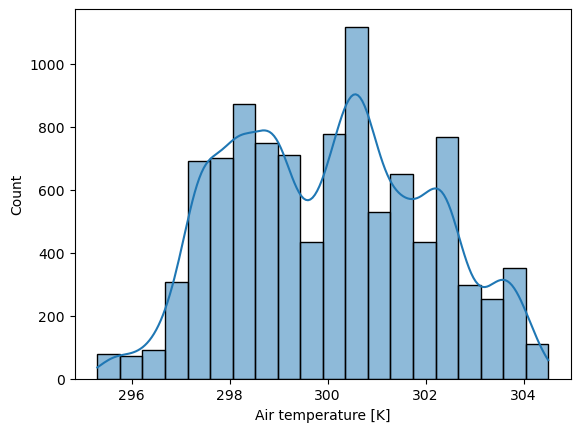

In [98]:
histogram('Air temperature [K]', df, True, 20)

(<Axes: xlabel='Process temperature [K]', ylabel='Count'>,
 'Histogram successfully plotted!',
 {'mean': np.float64(310.00555999999995),
  'median': 310.1,
  'std': 1.4837342191657419,
  'min': 305.7,
  'max': 313.8,
  'count': 10000,
  'skewness': np.float64(0.015027267769343768),
  'kurtosis': np.float64(-0.49973436501613966)})

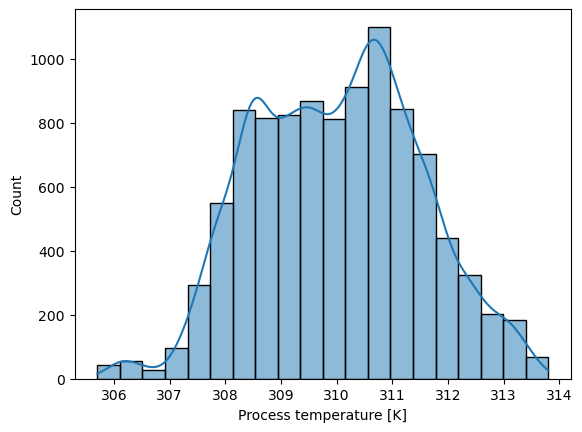

In [99]:
histogram('Process temperature [K]', df, True, 20)

In [100]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

(<Axes: xlabel='Rotational speed [rpm]', ylabel='Count'>,
 'Histogram successfully plotted!',
 {'mean': np.float64(1538.7761),
  'median': 1503.0,
  'std': 179.28409591342628,
  'min': 1168,
  'max': 2886,
  'count': 10000,
  'skewness': np.float64(1.993171004713752),
  'kurtosis': np.float64(7.392944899246482)})

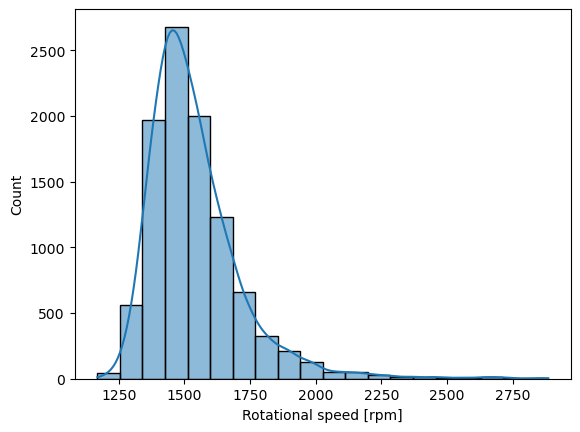

In [101]:
histogram('Rotational speed [rpm]', df, True, 20)

(<Axes: xlabel='Torque [Nm]', ylabel='Count'>,
 'Histogram successfully plotted!',
 {'mean': np.float64(39.986909999999995),
  'median': 40.1,
  'std': 9.968933725121401,
  'min': 3.8,
  'max': 76.6,
  'count': 10000,
  'skewness': np.float64(-0.009516595840058577),
  'kurtosis': np.float64(-0.013240614017022256)})

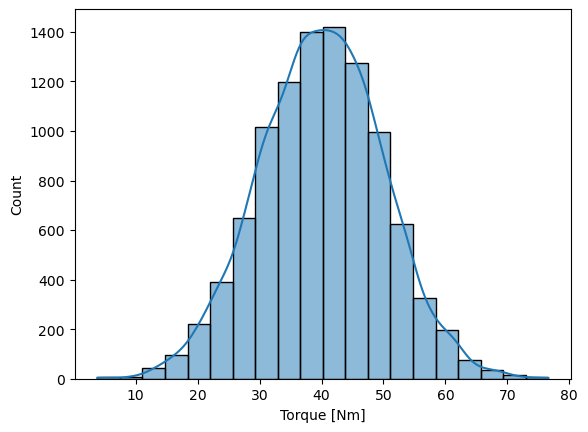

In [102]:
histogram('Torque [Nm]', df, True, 20)

(<Axes: xlabel='Tool wear [min]', ylabel='Count'>,
 'Histogram successfully plotted!',
 {'mean': np.float64(107.951),
  'median': 108.0,
  'std': 63.65414663663639,
  'min': 0,
  'max': 253,
  'count': 10000,
  'skewness': np.float64(0.027292239050452523),
  'kurtosis': np.float64(-1.166737131578055)})

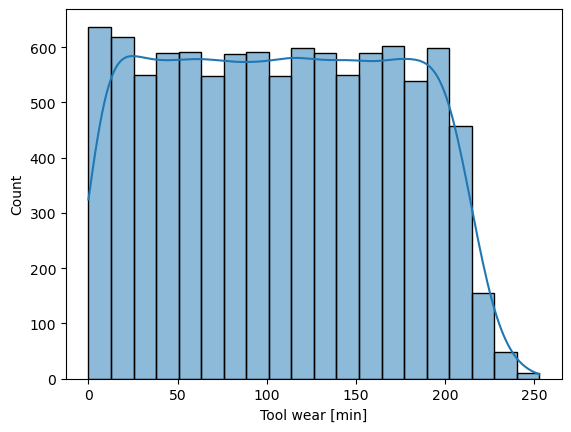

In [103]:
histogram('Tool wear [min]', df, True, 20)

In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from typing import Optional

def countplot(
    dataframe: pd.DataFrame,
    x: str,
    hue: Optional[str] = None
) -> Optional[Axes]:
    try:
        # Basic validation
        if dataframe is None or dataframe.empty:
            print("Error: DataFrame is None or empty")
            return None
        
        if x not in dataframe.columns:
            print(f"Error: Column '{x}' not found")
            return None
        
        if hue is not None and hue not in dataframe.columns:
            print(f"Error: Hue column '{hue}' not found")
            return None
        
        # Create plot
        plt.figure(figsize=(10, 6))
        
        ax = sns.countplot(
            data=dataframe,
            x=x,
            hue=hue
        )
        
        # Add count labels on bars
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(
                    str(int(height)),
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center',
                    va='bottom',
                    fontsize=10
                )
        
        # Set labels
        ax.set_title(f'Count of {x}' + (f' by {hue}' if hue else ''))
        ax.set_xlabel(x)
        ax.set_ylabel('Count')
        
        # Rotate x-labels if many categories
        if dataframe[x].nunique() > 5:
            plt.xticks(rotation=45, ha='right')
        
        if hue:
            ax.legend(title=hue)
        
        plt.tight_layout()
        return ax
        
    except Exception as err:
        print(f"Error: {err}")
        return None

<Axes: title={'center': 'Count of Type by Machine failure'}, xlabel='Type', ylabel='Count'>

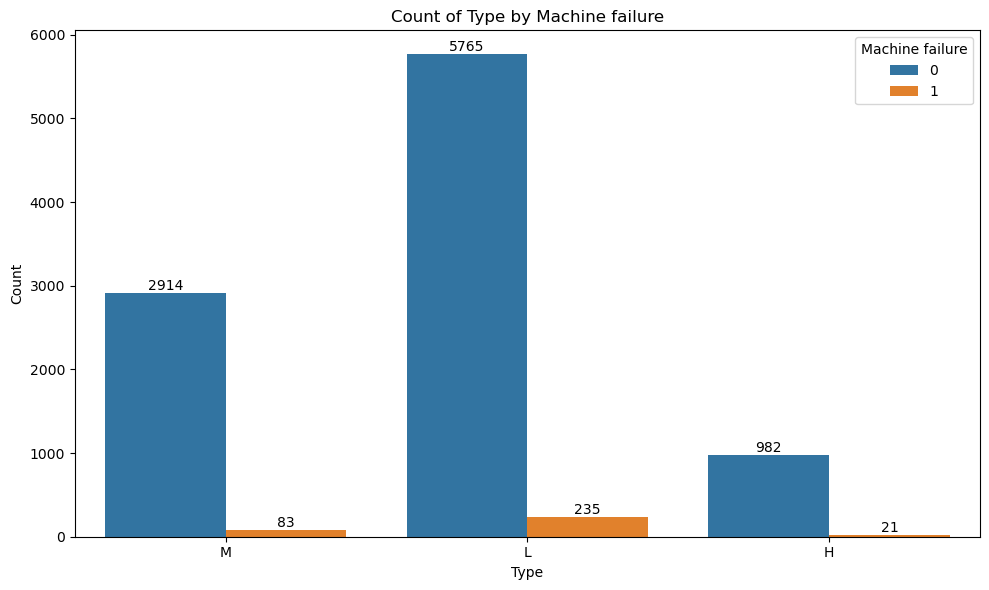

In [105]:
countplot(df, 'Type', hue='Machine failure')

In [106]:
from pandas.api.types import is_categorical_dtype, is_numeric_dtype
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from typing import Optional, Tuple, Dict, Any

def chi2_test(
    dataframe: pd.DataFrame,
    quan1: str,
    quan2: str
) -> Optional[Dict[str, Any]]:
    try:
        # Input Validation
        
        # Check DataFrame
        if dataframe is None:
            print("Err: DataFrame can't be None!")
            return None
        
        if not isinstance(dataframe, pd.DataFrame):
            print("Err: DataFrame is not an instance of pd.DataFrame")
            return None
        
        if len(dataframe) == 0:
            print("Err: Length of DataFrame is 0!")
            return None
        
        # Check columns
        if quan1 is None or quan2 is None:
            print("Err: Column names can't be None!")
            return None
        
        if quan1 == quan2:
            print("Err: Column names must be different!")
            return None
        
        # Check if columns exist in DataFrame
        if quan1 not in dataframe.columns:
            available_cols = dataframe.columns.tolist()
            print(f"Err: Column '{quan1}' doesn't exist in DataFrame!")
            print(f"Available columns: {available_cols}")
            return None
        
        if quan2 not in dataframe.columns:
            available_cols = dataframe.columns.tolist()
            print(f"Err: Column '{quan2}' doesn't exist in DataFrame!")
            print(f"Available columns: {available_cols}")
            return None
        
        # Check if columns have at least 2 unique values
        if dataframe[quan1].nunique() < 2:
            print(f"Err: Column '{quan1}' must have at least 2 unique values!")
            return None
        
        if dataframe[quan2].nunique() < 2:
            print(f"Err: Column '{quan2}' must have at least 2 unique values!")
            return None
        
        # Prepare Data
        
        # Remove rows with missing values
        clean_data = dataframe[[quan1, quan2]].dropna()
        
        if len(clean_data) == 0:
            print("Err: No valid data after removing missing values!")
            return None
        
        # Convert to categorical if needed (for chi-square)
        if not is_categorical_dtype(clean_data[quan1]):
            clean_data[quan1] = clean_data[quan1].astype('category')
        
        if not is_categorical_dtype(clean_data[quan2]):
            clean_data[quan2] = clean_data[quan2].astype('category')
        
        # Create contingency table
        contingency_table = pd.crosstab(
            clean_data[quan1],
            clean_data[quan2],
            dropna=False
        )
        
        # Perform Chi-Square Test 
        
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        # Calculate Effect Size (Cramer's V) 
        
        n = contingency_table.sum().sum()
        min_dim = min(contingency_table.shape) - 1
        
        if min_dim > 0:
            cramers_v = np.sqrt(chi2 / (n * min_dim))
        else:
            cramers_v = 0.0
        
        # Determine Significance 
        
        alpha = 0.05
        is_significant = p_value < alpha
        
        # Interpret Effect Size 
        
        if cramers_v < 0.1:
            effect_strength = "Negligible"
            practical_meaning = "No practical importance"
            business_impact = "This variable explains almost nothing"
        elif cramers_v < 0.2:
            effect_strength = "Weak"
            practical_meaning = "Small practical importance"
            business_impact = "This variable explains very little"
        elif cramers_v < 0.4:
            effect_strength = "Moderate"
            practical_meaning = "Medium practical importance"
            business_impact = "This variable has some relevance"
        elif cramers_v < 0.6:
            effect_strength = "Strong"
            practical_meaning = "Large practical importance"
            business_impact = "This variable is important"
        else:
            effect_strength = "Very Strong"
            practical_meaning = "Very large practical importance"
            business_impact = "This variable is critical"
        
        # Calculate Failure Rates (if binary) 
        
        failure_rates = {}
        for idx in contingency_table.index:
            total = contingency_table.loc[idx].sum()
            # Try to find failure column (usually 1 or 'failure')
            if 1 in contingency_table.columns:
                failures = contingency_table.loc[idx].get(1, 0)
            elif 'failure' in contingency_table.columns:
                failures = contingency_table.loc[idx].get('failure', 0)
            else:
                failures = contingency_table.loc[idx].iloc[:, -1]  # Last column
            failure_rates[idx] = (failures / total * 100) if total > 0 else 0
        
        # Build Result 
        
        result = {
            'chi2': chi2,
            'p_value': p_value,
            'degrees_of_freedom': dof,
            'is_significant': is_significant,
            'sample_size': n,
            'cramers_v': cramers_v,
            'effect_strength': effect_strength,
            'practical_meaning': practical_meaning,
            'business_impact': business_impact,
            'contingency_table': contingency_table,
            'failure_rates': failure_rates,
            'column1': quan1,
            'column2': quan2
        }
        
        return result
        
    except Exception as err:
        print(f"Err: Occurred due to: {err}")
        return None

In [107]:
chi2_test(df, 'Type', 'Machine failure')

{'chi2': np.float64(13.75171680114931),
 'p_value': np.float64(0.0010324110359454081),
 'degrees_of_freedom': 2,
 'is_significant': np.True_,
 'sample_size': np.int64(10000),
 'cramers_v': np.float64(0.03708330729742064),
 'effect_strength': 'Negligible',
 'practical_meaning': 'No practical importance',
 'business_impact': 'This variable explains almost nothing',
 'contingency_table': Machine failure     0    1
 Type                      
 H                 982   21
 L                5765  235
 M                2914   83,
 'failure_rates': {'H': np.float64(2.0937188434695915),
  'L': np.float64(3.916666666666667),
  'M': np.float64(2.7694361027694363)},
 'column1': 'Type',
 'column2': 'Machine failure'}

In [108]:
chi2_test(df, 'TWF', 'Machine failure')

{'chi2': np.float64(1287.522173876072),
 'p_value': np.float64(5.818865566703126e-282),
 'degrees_of_freedom': 1,
 'is_significant': np.True_,
 'sample_size': np.int64(10000),
 'cramers_v': np.float64(0.35882059220118234),
 'effect_strength': 'Moderate',
 'practical_meaning': 'Medium practical importance',
 'business_impact': 'This variable has some relevance',
 'contingency_table': Machine failure     0    1
 TWF                       
 0                9661  293
 1                   0   46,
 'failure_rates': {0: np.float64(2.9435402853124373), 1: np.float64(100.0)},
 'column1': 'TWF',
 'column2': 'Machine failure'}

In [109]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [110]:
chi2_test(df, 'HDF', 'Machine failure')

{'chi2': np.float64(3285.6835971979185),
 'p_value': np.float64(0.0),
 'degrees_of_freedom': 1,
 'is_significant': np.True_,
 'sample_size': np.int64(10000),
 'cramers_v': np.float64(0.5732088273219385),
 'effect_strength': 'Strong',
 'practical_meaning': 'Large practical importance',
 'business_impact': 'This variable is important',
 'contingency_table': Machine failure     0    1
 HDF                       
 0                9661  224
 1                   0  115,
 'failure_rates': {0: np.float64(2.2660596863935254), 1: np.float64(100.0)},
 'column1': 'HDF',
 'column2': 'Machine failure'}

In [111]:
chi2_test(df, 'PWF', 'Machine failure')

{'chi2': np.float64(2703.626157041439),
 'p_value': np.float64(0.0),
 'degrees_of_freedom': 1,
 'is_significant': np.True_,
 'sample_size': np.int64(10000),
 'cramers_v': np.float64(0.5199640523191424),
 'effect_strength': 'Strong',
 'practical_meaning': 'Large practical importance',
 'business_impact': 'This variable is important',
 'contingency_table': Machine failure     0    1
 PWF                       
 0                9661  244
 1                   0   95,
 'failure_rates': {0: np.float64(2.463402322059566), 1: np.float64(100.0)},
 'column1': 'PWF',
 'column2': 'Machine failure'}

In [112]:
chi2_test(df, 'OSF', 'Machine failure')

{'chi2': np.float64(2790.78451224742),
 'p_value': np.float64(0.0),
 'degrees_of_freedom': 1,
 'is_significant': np.True_,
 'sample_size': np.int64(10000),
 'cramers_v': np.float64(0.5282787627992839),
 'effect_strength': 'Strong',
 'practical_meaning': 'Large practical importance',
 'business_impact': 'This variable is important',
 'contingency_table': Machine failure     0    1
 OSF                       
 0                9661  241
 1                   0   98,
 'failure_rates': {0: np.float64(2.4338517471217935), 1: np.float64(100.0)},
 'column1': 'OSF',
 'column2': 'Machine failure'}

In [113]:
chi2_test(df, 'RNF', 'Machine failure')

{'chi2': np.float64(0.0),
 'p_value': np.float64(1.0),
 'degrees_of_freedom': 1,
 'is_significant': np.False_,
 'sample_size': np.int64(10000),
 'cramers_v': np.float64(0.0),
 'effect_strength': 'Negligible',
 'practical_meaning': 'No practical importance',
 'business_impact': 'This variable explains almost nothing',
 'contingency_table': Machine failure     0    1
 RNF                       
 0                9643  338
 1                  18    1,
 'failure_rates': {0: np.float64(3.386434225027552),
  1: np.float64(5.263157894736842)},
 'column1': 'RNF',
 'column2': 'Machine failure'}

In [114]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

(<Axes: xlabel='Process temperature [K]', ylabel='Count'>,
 'Histogram successfully plotted!',
 {'mean': np.float64(310.00555999999995),
  'median': 310.1,
  'std': 1.4837342191657419,
  'min': 305.7,
  'max': 313.8,
  'count': 10000,
  'skewness': np.float64(0.015027267769343768),
  'kurtosis': np.float64(-0.49973436501613966)})

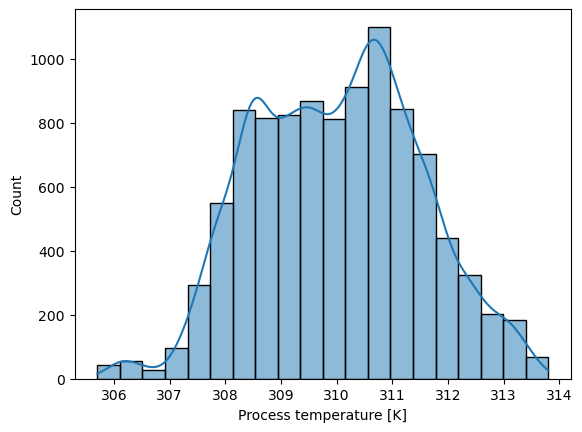

In [116]:
histogram('Process temperature [K]', df, True, 20)

In [119]:
df['Process temperature [K]'].describe()

count    10000.000000
mean       310.005560
std          1.483734
min        305.700000
25%        308.800000
50%        310.100000
75%        311.100000
max        313.800000
Name: Process temperature [K], dtype: float64

In [120]:
df['Air temperature [K]'].describe()

count    10000.000000
mean       300.004930
std          2.000259
min        295.300000
25%        298.300000
50%        300.100000
75%        301.500000
max        304.500000
Name: Air temperature [K], dtype: float64

In [121]:
df['Rotational speed [rpm]'].describe()

count    10000.000000
mean      1538.776100
std        179.284096
min       1168.000000
25%       1423.000000
50%       1503.000000
75%       1612.000000
max       2886.000000
Name: Rotational speed [rpm], dtype: float64

In [122]:
df['Tool wear [min]'].describe()

count    10000.000000
mean       107.951000
std         63.654147
min          0.000000
25%         53.000000
50%        108.000000
75%        162.000000
max        253.000000
Name: Tool wear [min], dtype: float64

In [124]:
df['Torque [Nm]'].describe()

count    10000.000000
mean        39.986910
std          9.968934
min          3.800000
25%         33.200000
50%         40.100000
75%         46.800000
max         76.600000
Name: Torque [Nm], dtype: float64

In [128]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

<Axes: title={'center': 'Count of Machine failure'}, xlabel='Machine failure', ylabel='Count'>

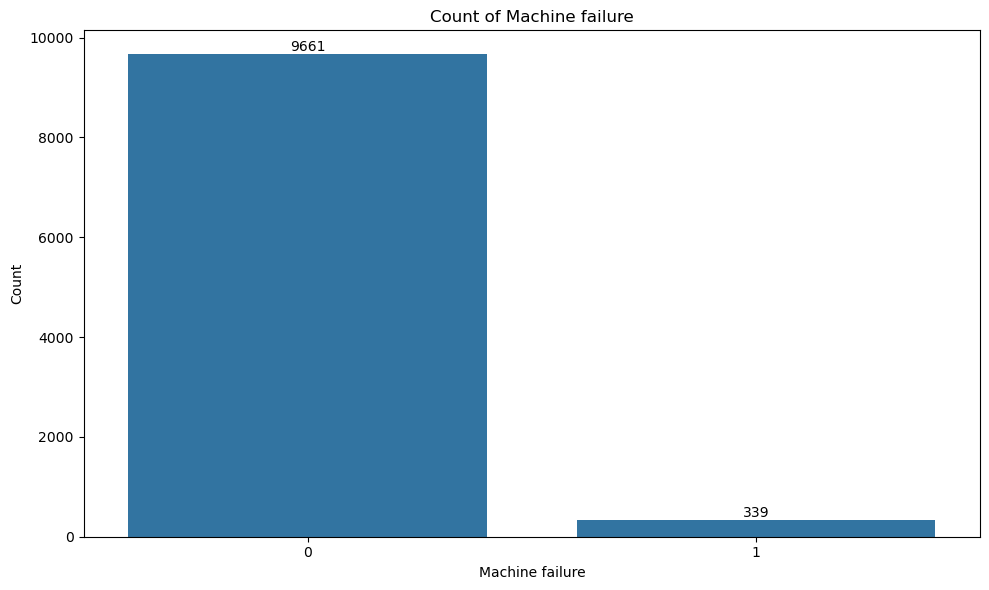

In [131]:
countplot(dataframe=df, x='Machine failure')

<Axes: title={'center': 'Count of TWF by Machine failure'}, xlabel='TWF', ylabel='Count'>

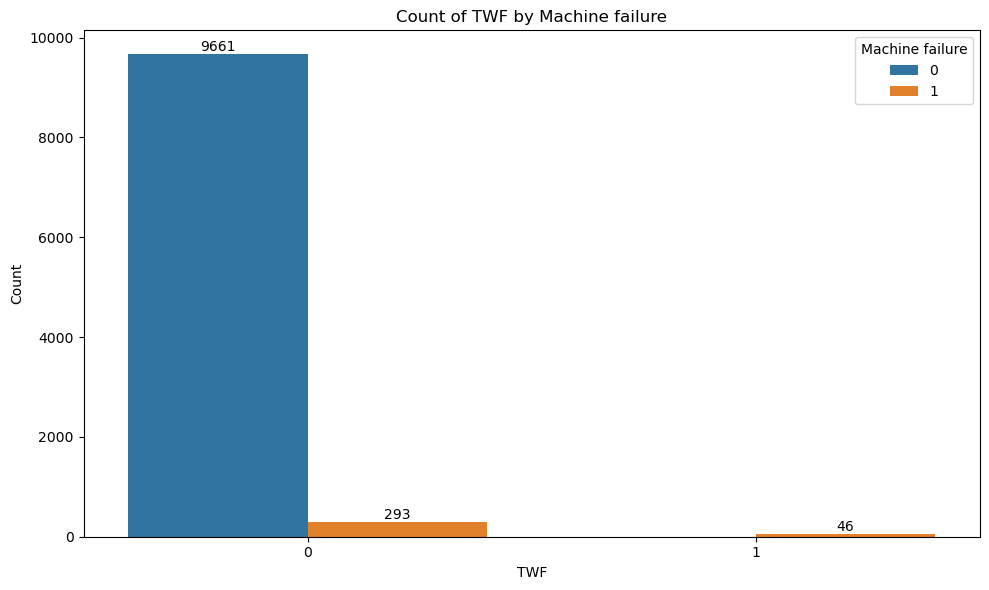

In [133]:
countplot(dataframe=df, x='TWF', hue='Machine failure')

<Axes: title={'center': 'Count of HDF by Machine failure'}, xlabel='HDF', ylabel='Count'>

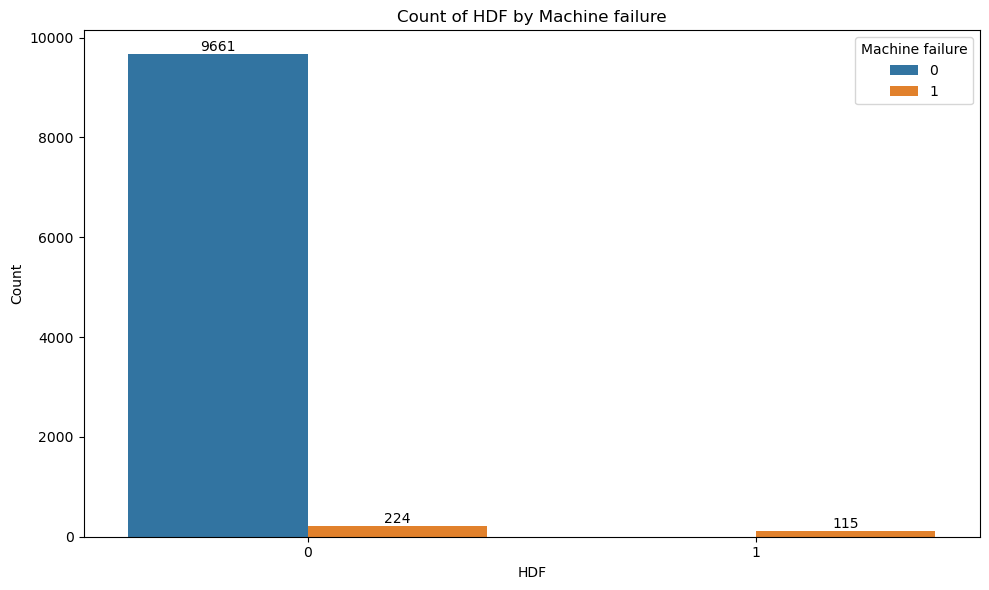

In [135]:
countplot(dataframe=df, x='HDF', hue='Machine failure')

<Axes: title={'center': 'Count of PWF by Machine failure'}, xlabel='PWF', ylabel='Count'>

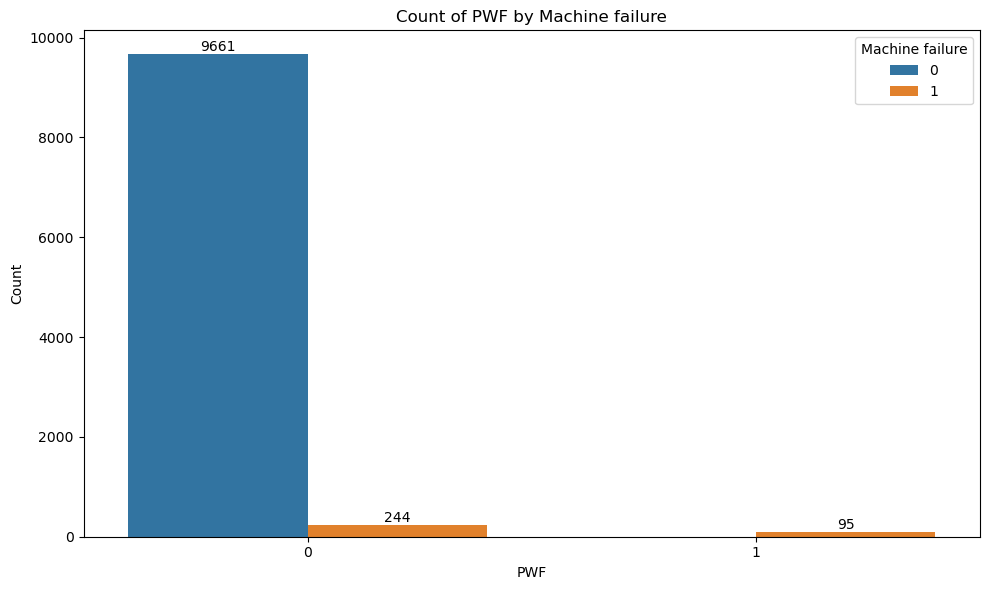

In [137]:
countplot(dataframe=df, x='PWF', hue='Machine failure')

<Axes: title={'center': 'Count of OSF by Machine failure'}, xlabel='OSF', ylabel='Count'>

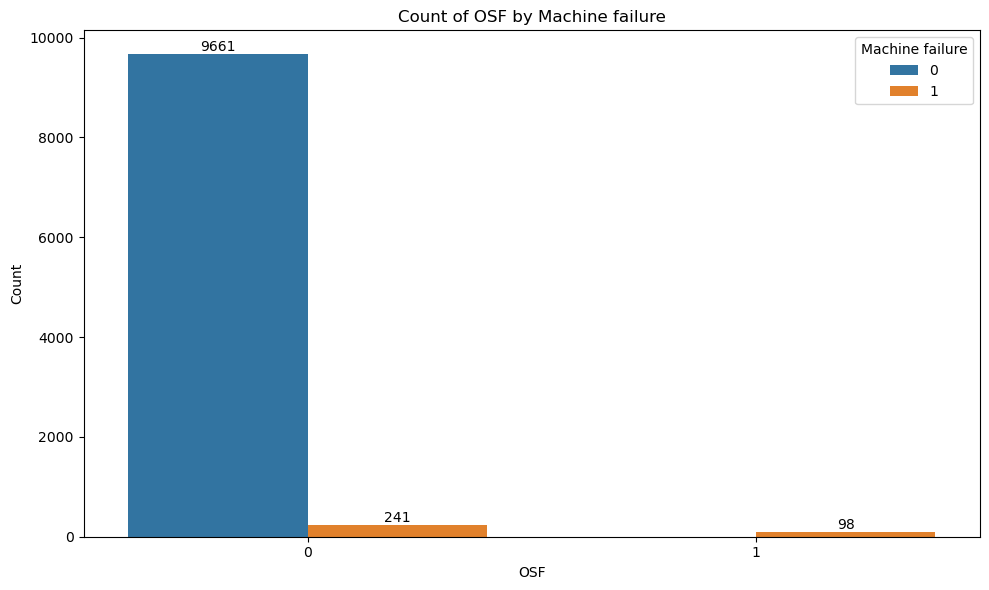

In [138]:
countplot(dataframe=df, x='OSF', hue='Machine failure')

In [144]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [149]:
from scipy.stats import mannwhitneyu

quantitative_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in quantitative_cols:

    group_0 = df[df["Machine failure"] == 0][col].dropna()
    group_1 = df[df["Machine failure"] == 1][col].dropna()

    statistic, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided"
    )

    print(f"\n{col}")
    print("U statistic:", statistic)
    print("p-value:", p_value)


Air temperature [K]
U statistic: 1202819.0
p-value: 8.656108133039112e-17

Process temperature [K]
U statistic: 1428896.5
p-value: 6.486083127989518e-05

Rotational speed [rpm]
U statistic: 2510959.0
p-value: 9.706907631568239e-63

Torque [Nm]
U statistic: 752493.0
p-value: 2.262232331232534e-64

Tool wear [min]
U statistic: 1106611.0
p-value: 2.9164608736257626e-24


In [151]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [154]:
from scipy.stats import kruskal

group_L = df[df["Type"] == "L"]["Torque [Nm]"].dropna()
group_M = df[df["Type"] == "M"]["Torque [Nm]"].dropna()
group_H = df[df["Type"] == "H"]["Torque [Nm]"].dropna()

statistic, p_value = kruskal(
    group_L,
    group_M,
    group_H
)

print("H statistic:", statistic)
print("p-value:", p_value)

H statistic: 0.06998690976251556
p-value: 0.9656117362803567


# Conclusion of EDA(Exploratory Data Analysis)

In [156]:
# Read all the theory carefully and create a mental model in your mind. 

# EDA showed that the dataset is generally well-structured, but some numerical features contain potential outliers that need to be
# handled during data cleaning. Rotational Speed has suspicious high values above 2100 rpm, while Torque has potential outliers
# below 10 Nm and above 70 Nm. Tool Wear contains boundary values such as 0 and 253 that should be reviewed rather than automatically removed.
# Air Temperature and Process Temperature appear well-behaved and can be kept as they are. The categorical analysis also showed that several
# categorical features have a statistically significant association with Machine Failure.

# Therefore, the next step is data cleaning, where suspicious outliers and unusual values will be investigated and handled carefully while
# preserving valid real-world observations.

In [157]:
# Your cleaning plan:

# Feature	               EDA finding	             Cleaning decision

# Rotational Speed	       High values > 2100 rpm	🔴 Investigate and handle
# Torque	               Values < 10 or > 70 Nm	🟡 Investigate and handle
# Tool Wear	               0 and 253	            🟡 Review before changing
# Process Temperature	  Well-behaved	            🟢 Keep 
# Air Temperature	      Well-behaved	            🟢 Keep

# Categorical features	Associations with failure found	🟢 Keep; don't remove just because significant

In [158]:
# One important correction: don't automatically DROP every outlier you found in EDA. An outlier can be a real machine observation, not an error.
# In data cleaning, first determine whether the value is impossible/invalid, a measurement issue, or a legitimate extreme observation.